**Dataset Loading and Exploration**

# Fake Review Detection on Shopee using Machine Learning
# Models: Naive Bayes, SVM, Random Forest
# Best Model: SVM
# Dataset: Shopee Multilingual Reviews (GitHub source)

In [1]:
import pandas as pd

# Load dataset directly from GitHub (reproducible)
url = "https://raw.githubusercontent.com/andrioktavianto/fake-review-shopee/master/train_review_only.csv"
df = pd.read_csv(url)

df.head()

,anonymous,author_shopid,author_username,cat_id,cmtid,comment,count_rating_with_image,count_with_context,ctime,editable,...,rating_count0,rating_count1,rating_count2,rating_count3,rating_count4,rating_count5,rating_star,shop_id,userid,fakeornot
0,False,80294228,icanursarah,2902,2327971512,"Hp sampai dengan selamat, berfungsi dengan bai...",922,2182,1588431497,1,...,7274,89,15,44,88,9088,5,15168157,80295702,fake
1,False,80294228,icanursarah,2902,2325993622,Mantabbagusmantabbagus yuhuuy\r\nRecommended s...,922,2182,1588403926,1,...,7274,89,15,44,88,9088,5,15168157,80295702,fake
2,False,80294228,icanursarah,2902,2325999143,Mantabbagusmantabbagus yuhuuy\r\nRecommended s...,922,2182,1588403984,1,...,7274,89,15,44,88,9088,5,15168157,80295702,fake
3,False,80294228,icanursarah,2902,2326001075,Mantabbagusmantabbagus yuhuuy\r\nRecommended s...,922,2182,1588404004,1,...,7274,89,15,44,88,9088,5,15168157,80295702,fake
4,False,16191982,rrp0811,2678,2361588821,Ini paket pertamaku beli disini.\r\nCepat\r\nT...,284,680,1589011931,1,...,1316,2,4,1,44,3584,5,134248812,16193318,fake


**Data Cleaning and Preprocessing**

In [ ]:
# Check how many missing values each column has
df.isnull().sum()


,0
anonymous,0
author_shopid,0
author_username,0
cat_id,0
cmtid,0
comment,1
count_rating_with_image,0
count_with_context,0
ctime,0
editable,0


In [ ]:
df = df.dropna(subset=['comment'])


In [ ]:
df['comment_stripped'] = df['comment'].astype(str).str.strip()
df = df[df['comment_stripped'] != ""]
df = df.drop(columns=['comment_stripped'])


In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_text'] = df['comment'].apply(clean_text)


In [ ]:
df = df[df['clean_text'].str.len() > 0]


In [ ]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
df = df[df['word_count'] >= 3]
df = df.drop(columns=['word_count'])


In [ ]:
print(df.isnull().sum())
print(df.shape)
df[['comment', 'clean_text', 'fakeornot']].head()


anonymous                   0
author_shopid               0
author_username             0
cat_id                      0
cmtid                       0
comment                     0
count_rating_with_image     0
count_with_context          0
ctime                       0
editable                    0
item_id                     0
mtime                       0
orderid                    98
product_title               0
rating                      0
rating_count0               0
rating_count1               0
rating_count2               0
rating_count3               0
rating_count4               0
rating_count5               0
rating_star                 0
shop_id                     0
userid                      0
fakeornot                   0
clean_text                  0
dtype: int64
(98, 26)


,comment,clean_text,fakeornot
0,"Hp sampai dengan selamat, berfungsi dengan bai...",hp sampai dengan selamat berfungsi dengan baik...,fake
1,Mantabbagusmantabbagus yuhuuy\r\nRecommended s...,mantabbagusmantabbagus yuhuuy recommended sell...,fake
2,Mantabbagusmantabbagus yuhuuy\r\nRecommended s...,mantabbagusmantabbagus yuhuuy recommended sell...,fake
3,Mantabbagusmantabbagus yuhuuy\r\nRecommended s...,mantabbagusmantabbagus yuhuuy recommended sell...,fake
4,Ini paket pertamaku beli disini.\r\nCepat\r\nT...,ini paket pertamaku beli disini cepat tanggap ...,fake


**Label Encoding**

In [ ]:
# Check unique values in fakeornot
df['fakeornot'].unique()


array(['fake', 'original'], dtype=object)

In [ ]:
df['fakeornot'] = df['fakeornot'].astype(str).str.lower().str.strip()


In [ ]:
df['fakeornot'] = df['fakeornot'].replace({
    'fake': 1,
    'original': 0
})


/tmp/ipython-input-3078953013.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fakeornot'] = df['fakeornot'].replace({


In [ ]:
df['fakeornot'].unique()


array([1, 0])

In [ ]:
unexpected = df[~df['fakeornot'].isin([0,1])]
unexpected.head()


,anonymous,author_shopid,author_username,cat_id,cmtid,comment,count_rating_with_image,count_with_context,ctime,editable,...,rating_count1,rating_count2,rating_count3,rating_count4,rating_count5,rating_star,shop_id,userid,fakeornot,clean_text


In [ ]:
df['fakeornot'] = df['fakeornot'].astype(int)


In [ ]:
df['fakeornot'].dtype


dtype('int64')

**Feature Engineering (TF-IDF Vectorization)**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    analyzer='word',
    min_df=2,
    max_df=0.90
)


In [ ]:
X = tfidf.fit_transform(df['clean_text'])
y = df['fakeornot']


**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


**Model Training**

In [ ]:
# STEP C: NAIVE BAYES MODEL


from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# 1. Initialise the model
# MultinomialNB is the standard choice for TF-IDF / count-based text features
nb_clf = MultinomialNB()

# 2. Train (fit) the model
nb_clf.fit(X_train, y_train)

# 3. Predict on the test set
y_pred = nb_clf.predict(X_test)

# 4. Basic metrics: accuracy, precision, recall, F1 (binary: fake = 1)
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average='binary', pos_label=1
)

print("=== Naive Bayes Performance (Fake = 1) ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# 5. Detailed classification report (for both classes: 0 = original, 1 = fake)
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['original (0)', 'fake (1)']))

# 6. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("=== Confusion Matrix ===")
print(cm)


=== Naive Bayes Performance (Fake = 1) ===
Accuracy : 0.9000
Precision: 1.0000
Recall   : 0.8000
F1-score : 0.8889

=== Classification Report ===
              precision    recall  f1-score   support

original (0)       0.83      1.00      0.91        10
    fake (1)       1.00      0.80      0.89        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20

=== Confusion Matrix ===
[[10  0]
 [ 2  8]]


In [ ]:
# STEP D: SVM MODEL (LinearSVC)

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# 1. Initialise the SVM model
# C controls regularization strength (smaller C = stronger regularization)
svm_clf = LinearSVC(C=1.0, random_state=42)

# 2. Train (fit) the model
svm_clf.fit(X_train, y_train)

# 3. Predict on the test set
y_pred_svm = svm_clf.predict(X_test)

# 4. Basic metrics: accuracy, precision, recall, F1 (for fake = 1)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm, recall_svm, f1_svm, _ = precision_recall_fscore_support(
    y_test, y_pred_svm, average='binary', pos_label=1
)

print("=== SVM (LinearSVC) Performance (Fake = 1) ===")
print(f"Accuracy : {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1-score : {f1_svm:.4f}")

# 5. Detailed classification report
print("\n=== Classification Report (SVM) ===")
print(classification_report(y_test, y_pred_svm, target_names=['original (0)', 'fake (1)']))

# 6. Confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("=== Confusion Matrix (SVM) ===")
print(cm_svm)


=== SVM (LinearSVC) Performance (Fake = 1) ===
Accuracy : 0.9000
Precision: 0.9000
Recall   : 0.9000
F1-score : 0.9000

=== Classification Report (SVM) ===
              precision    recall  f1-score   support

original (0)       0.90      0.90      0.90        10
    fake (1)       0.90      0.90      0.90        10

    accuracy                           0.90        20
   macro avg       0.90      0.90      0.90        20
weighted avg       0.90      0.90      0.90        20

=== Confusion Matrix (SVM) ===
[[9 1]
 [1 9]]


In [ ]:
# STEP E: RANDOM FOREST MODEL

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# 1. Initialize the Random Forest Model
rf_clf = RandomForestClassifier(
    n_estimators=300,        # number of trees
    max_depth=None,          # let trees expand fully
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1                # use all CPU cores
)

# 2. Train (fit) the model
rf_clf.fit(X_train, y_train)

# 3. Predict on test set
y_pred_rf = rf_clf.predict(X_test)

# 4. Basic metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf, recall_rf, f1_rf, _ = precision_recall_fscore_support(
    y_test, y_pred_rf, average='binary', pos_label=1
)

print("=== Random Forest Performance (Fake = 1) ===")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")

# 5. Detailed classification report
print("\n=== Classification Report (Random Forest) ===")
print(classification_report(
    y_test, y_pred_rf,
    target_names=['original (0)', 'fake (1)']
))

# 6. Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("=== Confusion Matrix (Random Forest) ===")
print(cm_rf)


=== Random Forest Performance (Fake = 1) ===
Accuracy : 0.8500
Precision: 0.8182
Recall   : 0.9000
F1-score : 0.8571

=== Classification Report (Random Forest) ===
              precision    recall  f1-score   support

original (0)       0.89      0.80      0.84        10
    fake (1)       0.82      0.90      0.86        10

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20

=== Confusion Matrix (Random Forest) ===
[[8 2]
 [1 9]]


**Model Evaluation**

In [ ]:
import pandas as pd

results = {
    'Model': ['Naive Bayes', 'SVM (LinearSVC)', 'Random Forest'],
    'Accuracy': [accuracy, accuracy_svm, accuracy_rf],
    'Precision (Fake=1)': [precision, precision_svm, precision_rf],
    'Recall (Fake=1)': [recall, recall_svm, recall_rf],
    'F1-score (Fake=1)': [f1, f1_svm, f1_rf]
}

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision (Fake=1),Recall (Fake=1),F1-score (Fake=1)
0,Naive Bayes,0.90,1.000000,0.8,0.888889
1,SVM (LinearSVC),0.90,0.900000,0.9,0.900000
2,Random Forest,0.85,0.818182,0.9,0.857143


**Model Comparison**

In [ ]:
print("=== MODEL PERFORMANCE COMPARISON ===")
# If you intended to sort the DataFrame, uncomment and run the following line:
# results_df_sorted = results_df.sort_values(by='F1-score (Fake=1)', ascending=False)
print(results_df.to_string(index=False))

=== MODEL PERFORMANCE COMPARISON ===
          Model  Accuracy  Precision (Fake=1)  Recall (Fake=1)  F1-score (Fake=1)
    Naive Bayes      0.90            1.000000              0.8           0.888889
SVM (LinearSVC)      0.90            0.900000              0.9           0.900000
  Random Forest      0.85            0.818182              0.9           0.857143


Naive Bayes is very accurate when it predicts a fake review, but it misses some fake reviews. SVM is more balanced because it detects more fake reviews while still keeping high accuracy.



**Model Comparison Visualization**

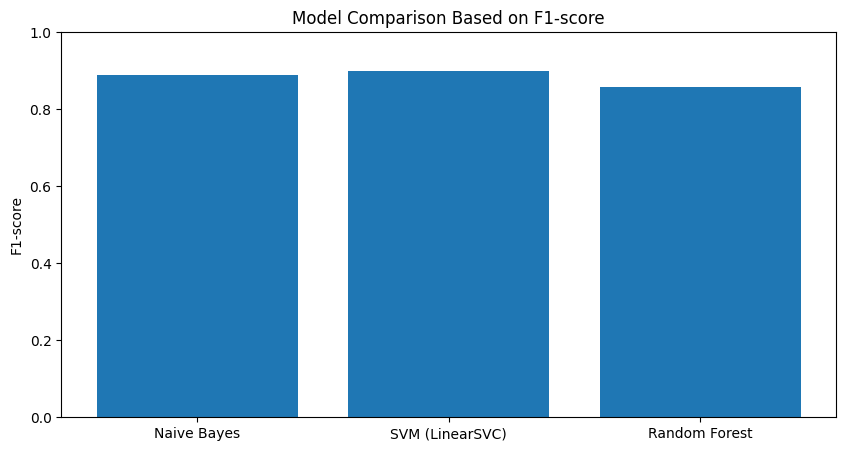

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(results_df['Model'], results_df['F1-score (Fake=1)'])
plt.title('Model Comparison Based on F1-score')
plt.ylabel('F1-score')
plt.ylim(0, 1)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Original (0)', 'Predicted Fake (1)'],
                yticklabels=['Actual Original (0)', 'Actual Fake (1)'])
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


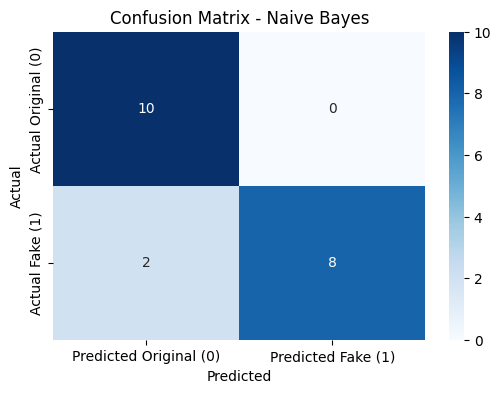

In [ ]:
plot_confusion_matrix(cm, "Confusion Matrix - Naive Bayes")


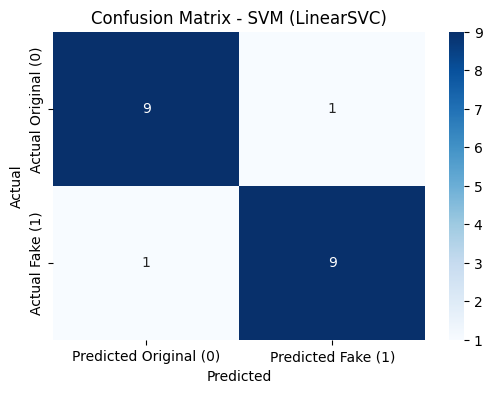

In [ ]:
plot_confusion_matrix(cm_svm, "Confusion Matrix - SVM (LinearSVC)")


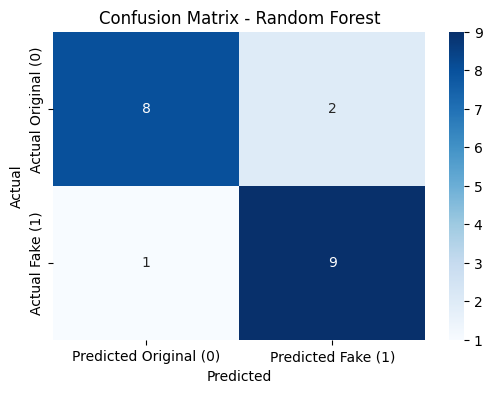

In [ ]:
plot_confusion_matrix(cm_rf, "Confusion Matrix - Random Forest")


In [ ]:
import pandas as pd

# --- 1) Make sure you have the original text aligned with the same split ---
# If you already have df with columns like: df['review'] and df['label']
# Do the split using the raw text first so indices stay aligned.

from sklearn.model_selection import train_test_split

# Change these to match your actual column names:
TEXT_COL = "comment"   # e.g., "review" or "text"
LABEL_COL = "fakeornot"   # e.g., "label"

X = df[TEXT_COL].astype(str)
y = df[LABEL_COL].astype(int)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --- 2) After you predict with your model (example) ---
# For this example, y_pred is taken from the last trained Naive Bayes model.
# If you want to use predictions from other models, update y_pred accordingly (e.g., y_pred_svm or y_pred_rf).
# y_pred = model.predict(X_test_tfidf)

# --- 3) Build a table to inspect test cases ---
cases = pd.DataFrame({
    "review": X_test_text.values,
    "y_true": y_test.values,
    "y_pred": y_pred
})

# Create a human-readable category
def cat(row):
    if row.y_true == 1 and row.y_pred == 1:
        return "TP (Fake → Fake)"
    if row.y_true == 0 and row.y_pred == 0:
        return "TN (Original → Original)"
    if row.y_true == 0 and row.y_pred == 1:
        return "FP (Original → Fake)"
    return "FN (Fake → Original)"

cases["category"] = cases.apply(cat, axis=1)

# Optional: add review length (helps explain why short reviews get misclassified)
cases["length"] = cases["review"].str.len()

cases["category"].value_counts()

,count
category,
TN (Original → Original),10
TP (Fake → Fake),8
FN (Fake → Original),2


In [ ]:
def show_examples(category, n=3, sort_by="length", ascending=True):
    subset = cases[cases["category"] == category].copy()
    subset = subset.sort_values(sort_by, ascending=ascending)
    return subset[["category", "length", "review"]].head(n)

tp_examples = show_examples("TP (Fake → Fake)", n=3)
tn_examples = show_examples("TN (Original → Original)", n=3)
fp_examples = show_examples("FP (Original → Fake)", n=3)
fn_examples = show_examples("FN (Fake → Original)", n=3)

tp_examples, tn_examples, fp_examples, fn_examples


(           category  length                                             review
 0  TP (Fake → Fake)      57  Mantaabbb mantaabbb mantaabbb\r\nRecommended s...
 7  TP (Fake → Fake)      57  Mantaabbb mantaabbb mantaabbb\r\nRecommended s...
 3  TP (Fake → Fake)      59  Mantabbagusmantabbagus yuhuuy\r\nRecommended s...,
                     category  length  \
 10  TN (Original → Original)      28   
 8   TN (Original → Original)      38   
 12  TN (Original → Original)      59   
 
                                                review  
 10                       sejauh ini blom ada problem   
 8              Semoga awet sampai 30 hari ya, aminnnn  
 12  Agak lama, tp gpp maklum namanya jg murah hehe...  ,
 Empty DataFrame
 Columns: [category, length, review]
 Index: [],
                 category  length  \
 2   FN (Fake → Original)     185   
 11  FN (Fake → Original)     250   
 
                                                review  
 2   Kualitas oke bangettt respon penjual sangat

In [ ]:
# Only if your model supports predict_proba()
proba = nb_clf.predict_proba(X_test)[:, 1]  # probability of class 1 (fake)
cases["p_fake"] = proba

# Most confident TP (fake predicted fake with high probability)
cases[cases["category"]=="TP (Fake → Fake)"].sort_values("p_fake", ascending=False).head(3)

,review,y_true,y_pred,category,length,p_fake
3,Mantabbagusmantabbagus yuhuuy\r\nRecommended s...,1,1,TP (Fake → Fake),59,0.960519
1,Mantab mantab mantab jiwa\r\nYuhuuuyyy\r\nReco...,1,1,TP (Fake → Fake),60,0.952199
0,Mantaabbb mantaabbb mantaabbb\r\nRecommended s...,1,1,TP (Fake → Fake),57,0.900560


**Saving Model**

In [ ]:
import joblib


In [ ]:
joblib.dump(nb_clf, "naive_bayes_model.joblib")


['naive_bayes_model.joblib']

In [ ]:
joblib.dump(svm_clf, "svm_model.joblib")


['svm_model.joblib']

In [ ]:
joblib.dump(rf_clf, "random_forest_model.joblib")


['random_forest_model.joblib']

In [ ]:
joblib.dump(tfidf, "tfidf_vectorizer.joblib")


['tfidf_vectorizer.joblib']

In [ ]:
joblib.dump((X_train, X_test, y_train, y_test), "dataset_split.joblib")


['dataset_split.joblib']

In [ ]:
joblib.dump((X_train, X_test, y_train, y_test), "dataset_split.joblib")


['dataset_split.joblib']

In [ ]:
nb_model = joblib.load("naive_bayes_model.joblib")
svm_model = joblib.load("svm_model.joblib")
rf_model = joblib.load("random_forest_model.joblib")
tfidf_loaded = joblib.load("tfidf_vectorizer.joblib")
